# Annealed paths and free energy: weighting whole trajectories

Annealed importance sampling (AIS) inserts intermediate distributions between an easy
reference law and a difficult target. The product of incremental density ratios estimates a
normalizing-constant ratio. Resampling turns the method into annealed sequential Monte Carlo,
trading weight concentration for dependence and genealogical collapse.

This notebook uses the public `sampler_lab.annealing`, `sampler_lab.particles`, and
`sampler_lab.models` namespaces.

**Output semantics:** weighted path estimates; approximate final particle populations;
unbiased ratio estimates under the AIS/SMC construction. IID Jarzynski uncertainty formulas
apply only when no resampling occurred.

Related pages: [annealed paths and free energies](../methods/annealed_paths.md),
[particle methods](03_particle_methods.ipynb), and [public API](../api.md).


In [1]:
import importlib.metadata
import os

import matplotlib.pyplot as plt
import numpy as np

from sampler_lab import spawn_rngs
from sampler_lab.annealing import (
    AnnealingSchedule,
    GeometricAnnealingPath,
    IdentityPopulationTransition,
    annealed_importance_sampling,
    jarzynski_estimate,
    reweight_cloud,
)
from sampler_lab.models import (
    IsingGibbsPopulationTransition,
    IsingModel,
    exact_ising_distribution,
)
from sampler_lab.particles import ParticleCloud, SystematicResampler

QUICK_MODE = os.environ.get("SAMPLER_LAB_NOTEBOOK_MODE") == "quick"
SEED = 2022
FIGURE_COUNT = 0


def finish_figure(fig):
    global FIGURE_COUNT
    fig.tight_layout()
    plt.show()
    plt.close(fig)
    FIGURE_COUNT += 1


print("sampler-lab", importlib.metadata.version("sampler-lab"))
print("execution mode:", "quick" if QUICK_MODE else "publication")
print("master seed:", SEED)

sampler-lab 0.12.0
execution mode: publication
master seed: 2022


## 1. Path and schedule

A geometric path between unnormalized densities $\gamma_0$ and $\gamma_1$ is

$$
\log\gamma_\beta(x)=(1-\beta)\log\gamma_0(x)+\beta\log\gamma_1(x),
\qquad 0\le\beta\le1.
$$

The schedule chooses $0=\beta_0<\cdots<\beta_K=1$. At stage $k$, AIS adds

$$
\Delta\ell_k=\log\gamma_{\beta_k}(X_{k-1})
-\log\gamma_{\beta_{k-1}}(X_{k-1}),
$$

then applies a transition invariant for the new intermediate law.

We anneal a $2\times2$ Ising model from infinite temperature ($\beta=0$) to a target inverse
temperature. Exact enumeration supplies the partition-function ratio and magnetization law.


In [2]:
lattice_size = 2
target_beta = 0.85
initial_model = IsingModel(lattice_size, 0.0)
target_model = IsingModel(lattice_size, target_beta)
path = GeometricAnnealingPath(initial_model, target_model)
schedule = AnnealingSchedule.linear(8)
exact_target = exact_ising_distribution(target_model)
exact_log_ratio = exact_target.log_partition - target_model.n_sites * np.log(2.0)

probe = np.ones((lattice_size, lattice_size))
print("schedule:", np.round(schedule.values, 3))
print("log density at beta=0:", path.log_unnormalized(probe, 0.0))
print("log density at beta=1:", path.log_unnormalized(probe, 1.0))
print("exact log Z ratio:", round(float(exact_log_ratio), 6))

schedule: [0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875 1.   ]
log density at beta=0: 0.0
log density at beta=1: 6.8
exact log Z ratio: 4.72722


The intermediate Ising laws visibly move mass toward strongly magnetized configurations. The
next plot shows exact absolute-magnetization distributions along the path. A schedule that
crosses this change too abruptly will create highly variable incremental weights.


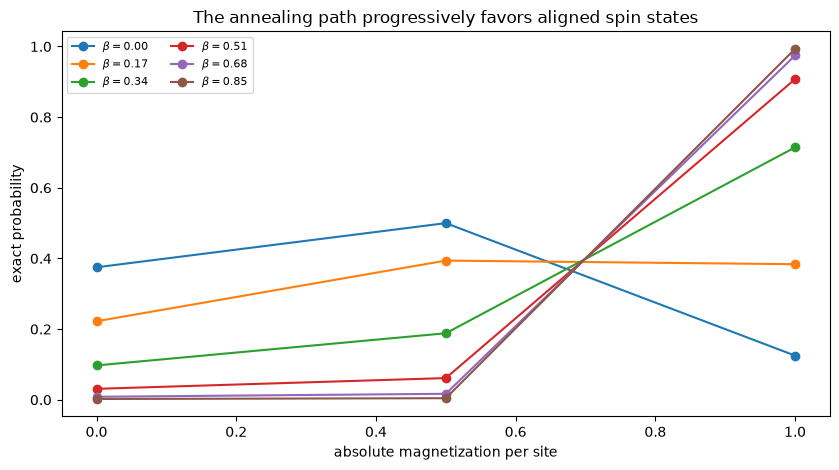

In [3]:
beta_grid = np.linspace(0.0, target_beta, 6)
support = np.array([0.0, 0.5, 1.0])
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for beta in beta_grid:
    exact = exact_ising_distribution(IsingModel(lattice_size, float(beta)))
    absolute = np.abs(exact.magnetizations) / target_model.n_sites
    probabilities = np.array(
        [np.sum(exact.probabilities[np.isclose(absolute, value)]) for value in support]
    )
    ax.plot(support, probabilities, "o-", label=rf"$\beta={beta:.2f}$")
ax.set_xlabel("absolute magnetization per site")
ax.set_ylabel("exact probability")
ax.set_title("The annealing path progressively favors aligned spin states")
ax.legend(ncol=2, fontsize=8)
finish_figure(fig)

## 2. Minimal AIS and annealed SMC calls

We use one deterministic Gibbs sweep per stage as the population transition. Ordinary AIS
keeps complete independent trajectories and accumulates their log weights. The SMC variant
triggers systematic resampling when pre-resampling ESS drops below $0.7N$.


In [4]:
n_particles = 900 if QUICK_MODE else 5000
run_rngs = spawn_rngs(SEED + 300, 2)


def initial_particles(rng, count):
    return np.asarray(
        2 * rng.integers(0, 2, size=(count, lattice_size, lattice_size)) - 1,
        dtype=np.float64,
    )


transition = IsingGibbsPopulationTransition(lattice_size, target_beta, n_sweeps=1)
ais = annealed_importance_sampling(
    initial_particles(run_rngs[0], n_particles),
    path,
    schedule,
    transition,
    run_rngs[0],
)
smc = annealed_importance_sampling(
    initial_particles(run_rngs[1], n_particles),
    path,
    schedule,
    transition,
    run_rngs[1],
    resampler=SystematicResampler(),
    resample_ess_fraction=0.70,
)

for name, result in (("AIS", ais), ("ESS-resampled SMC", smc)):
    absolute_magnetization = result.final_cloud.expectation(
        lambda particles: np.abs(np.sum(particles, axis=(1, 2))) / target_model.n_sites
    )
    print(
        f"{name:>18}: log ratio={result.log_normalizing_constant_ratio:.6f}, "
        f"error={result.log_normalizing_constant_ratio - exact_log_ratio:+.6f}, "
        f"E|m|={absolute_magnetization:.5f}, "
        f"resampling stages={np.count_nonzero(result.resampled)}"
    )

               AIS: log ratio=4.717048, error=-0.010172, E|m|=0.99589, resampling stages=0
 ESS-resampled SMC: log ratio=4.761404, error=+0.034184, E|m|=0.99433, resampling stages=2


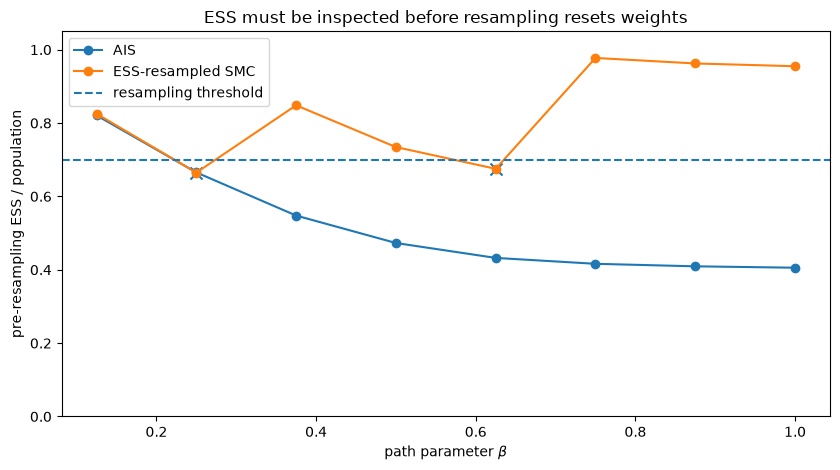

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for name, result in (("AIS", ais), ("ESS-resampled SMC", smc)):
    population = np.array([cloud.n_particles for cloud in result.weighted_clouds], dtype=np.float64)
    ess_fraction = result.ess_history / population
    ax.plot(result.schedule.values[1:], ess_fraction, "o-", label=name)
    triggered = np.flatnonzero(result.resampled)
    if triggered.size:
        ax.scatter(
            result.schedule.values[1:][triggered],
            ess_fraction[triggered],
            marker="x",
            s=75,
        )
ax.axhline(0.70, linestyle="--", label="resampling threshold")
ax.set_xlabel(r"path parameter $\beta$")
ax.set_ylabel("pre-resampling ESS / population")
ax.set_ylim(0.0, 1.05)
ax.set_title("ESS must be inspected before resampling resets weights")
ax.legend()
finish_figure(fig)

## 3. Work distributions and the Jarzynski sign convention

Sampler Lab defines reduced work by $W=-\sum_k\Delta\ell_k$, so

$$
\mathbb E[e^{-W}]=Z_1/Z_0,
\qquad \Delta F=-\log(Z_1/Z_0).
$$

The exponential average is controlled by the low-work tail. A broad work distribution can
make most trajectories visually irrelevant to the estimate. For unresampled AIS, the package
reports the elementary IID delta-method uncertainty; after resampling that formula is disabled
because trajectories are coupled and duplicated.


ratio estimate: 111.83757868385383
log ratio estimate: 4.717047628428659
free-energy estimate: -4.717047628428659
delta-method standard error: 0.017122205409739813
resampled uncertainty guard: IID Jarzynski uncertainty is invalid after resampling


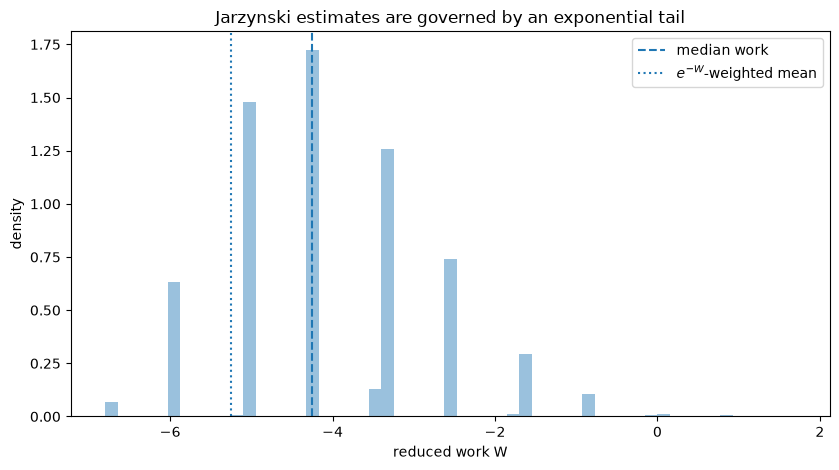

In [6]:
work = ais.final_reduced_work
jarzynski = ais.iid_jarzynski_estimate()
direct = jarzynski_estimate(work)
print("ratio estimate:", direct.ratio.value)
print("log ratio estimate:", direct.ratio.log_value)
print("free-energy estimate:", direct.delta_free_energy)
print("delta-method standard error:", direct.standard_error)

try:
    smc.iid_jarzynski_estimate()
except ValueError as error:
    print("resampled uncertainty guard:", error)
else:
    raise AssertionError("resampled SMC must not expose IID Jarzynski uncertainty")

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.hist(work, bins=55, density=True, histtype="stepfilled", alpha=0.45)
ax.axvline(np.median(work), linestyle="--", label="median work")
weighted_mean_work = np.average(work, weights=np.exp(-work - np.max(-work)))
ax.axvline(weighted_mean_work, linestyle=":", label=r"$e^{-W}$-weighted mean")
ax.set_xlabel("reduced work W")
ax.set_ylabel("density")
ax.set_title("Jarzynski estimates are governed by an exponential tail")
ax.legend()
finish_figure(fig)

## 4. Schedule resolution and movement study

More intermediate distributions reduce each density-ratio jump, but they also cost more
transition work. We repeat estimates across schedule lengths for two transition choices:

- an identity transition, which is invariant but performs no rejuvenation;
- one Gibbs sweep per stage.

This is a controlled failure: an invariant identity kernel is mathematically legal and
practically poor. Increasing the number of path points helps, but it cannot manufacture
movement between modes.


In [7]:
step_grid = np.array([1, 2, 4, 8] if QUICK_MODE else [1, 2, 4, 8, 16, 32])
replicates = 4 if QUICK_MODE else 14
study_particles = 450 if QUICK_MODE else 1800
study_rngs = iter(spawn_rngs(SEED + 310, 2 * replicates * step_grid.size))
errors = {"identity transition": [], "one Gibbs sweep": []}
minimum_ess = {"identity transition": [], "one Gibbs sweep": []}

for steps in step_grid:
    study_schedule = AnnealingSchedule.linear(int(steps))
    configurations = {
        "identity transition": IdentityPopulationTransition(),
        "one Gibbs sweep": IsingGibbsPopulationTransition(lattice_size, target_beta, n_sweeps=1),
    }
    for _ in range(replicates):
        for name, move in configurations.items():
            rng = next(study_rngs)
            result = annealed_importance_sampling(
                initial_particles(rng, study_particles),
                path,
                study_schedule,
                move,
                rng,
            )
            errors[name].append((steps, result.log_normalizing_constant_ratio - exact_log_ratio))
            minimum_ess[name].append((steps, np.min(result.ess_history / study_particles)))

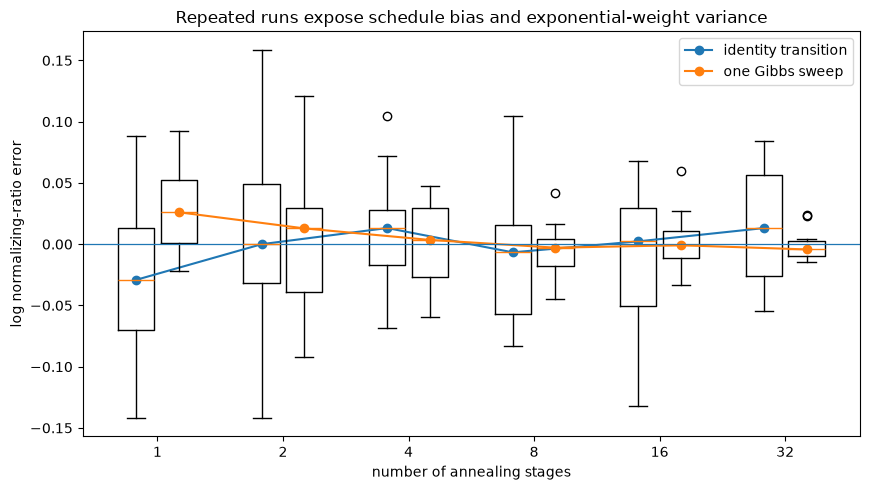

In [8]:
fig, ax = plt.subplots(figsize=(8.8, 5.0))
positions = np.arange(step_grid.size)
width = 0.34
for offset, (name, values) in zip((-width / 2, width / 2), errors.items(), strict=True):
    data = np.asarray(values, dtype=np.float64)
    groups = [data[data[:, 0] == steps, 1] for steps in step_grid]
    ax.boxplot(
        groups,
        positions=positions + offset,
        widths=width * 0.85,
        patch_artist=False,
        manage_ticks=False,
    )
    medians = [np.median(group) for group in groups]
    ax.plot(positions + offset, medians, "o-", label=name)
ax.axhline(0.0, linewidth=0.9)
ax.set_xticks(positions, step_grid)
ax.set_xlabel("number of annealing stages")
ax.set_ylabel("log normalizing-ratio error")
ax.set_title("Repeated runs expose schedule bias and exponential-weight variance")
ax.legend()
finish_figure(fig)

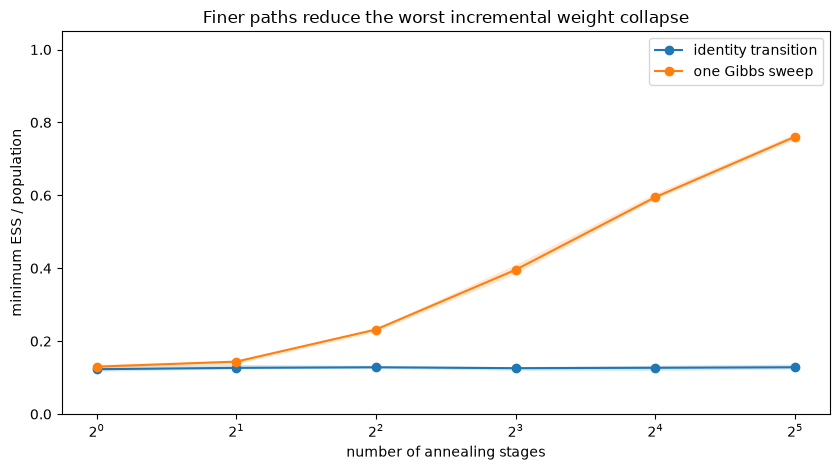

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for name, values in minimum_ess.items():
    data = np.asarray(values, dtype=np.float64)
    medians = [np.median(data[data[:, 0] == steps, 1]) for steps in step_grid]
    lower = [np.quantile(data[data[:, 0] == steps, 1], 0.2) for steps in step_grid]
    upper = [np.quantile(data[data[:, 0] == steps, 1], 0.8) for steps in step_grid]
    ax.plot(step_grid, medians, "o-", label=name)
    ax.fill_between(step_grid, lower, upper, alpha=0.18)
ax.set_xscale("log", base=2)
ax.set_xlabel("number of annealing stages")
ax.set_ylabel("minimum ESS / population")
ax.set_ylim(0.0, 1.05)
ax.set_title("Finer paths reduce the worst incremental weight collapse")
ax.legend()
finish_figure(fig)

## 5. Intermediate-state reweighting

A cloud approximating $\pi_{\beta_a}$ can be reweighted toward $\pi_{\beta_b}$ without
mutation. This is useful for diagnostics and short bridges, but the resulting ESS quantifies
how far the cloud can be pushed before a new transition or resampling step is needed.


In [10]:
source_beta = 0.35
target_beta_for_reweighting = 0.75
source_model = IsingModel(lattice_size, source_beta * target_beta)
source_exact = exact_ising_distribution(source_model)
source_rng = np.random.default_rng(SEED + 320)
source_indices = source_rng.choice(
    source_exact.probabilities.size,
    size=1200 if QUICK_MODE else 6000,
    p=source_exact.probabilities,
)
source_particles = source_exact.states[source_indices]
source_cloud = ParticleCloud.uniform(source_particles)
reweighted = reweight_cloud(
    source_cloud,
    path,
    source_beta,
    target_beta_for_reweighting,
)
print("source cloud ESS:", source_cloud.effective_sample_size)
print("reweighted cloud ESS:", round(reweighted.effective_sample_size, 2))
print(
    "reweighted ESS fraction:", round(reweighted.effective_sample_size / reweighted.n_particles, 4)
)

source cloud ESS: 6000.000000000013
reweighted cloud ESS: 4062.72
reweighted ESS fraction: 0.6771


## When to use annealed paths

AIS and annealed SMC are useful for partition functions, free-energy differences, and targets
that can be connected to an easy reference law. Their main tuning objects are the path,
schedule, invariant transitions, particle count, and resampling rule. Monitor incremental
weights, pre-resampling ESS, work tails, and ancestry together.

Further experiments:

- replace the linear schedule by a power schedule concentrated near the difficult end;
- compare fixed-stage and ESS-triggered resampling at equal spin-update cost;
- increase target inverse temperature until the identity-transition failure becomes severe.


In [11]:
good_error = abs(ais.log_normalizing_constant_ratio - exact_log_ratio)
exact_abs_magnetization = exact_target.expectation(
    np.abs(exact_target.magnetizations) / target_model.n_sites
)
estimated_abs_magnetization = ais.final_cloud.expectation(
    lambda particles: np.abs(np.sum(particles, axis=(1, 2))) / target_model.n_sites
)
print("AIS absolute log-ratio error:", round(float(good_error), 6))
print("exact E|m|:", round(float(exact_abs_magnetization), 6))
print("AIS E|m|:", round(float(estimated_abs_magnetization), 6))

assert np.isclose(jarzynski.ratio.log_value, ais.log_normalizing_constant_ratio)
assert good_error < (0.25 if QUICK_MODE else 0.10)
assert abs(estimated_abs_magnetization - exact_abs_magnetization) < (0.12 if QUICK_MODE else 0.05)
assert FIGURE_COUNT >= 5
print(f"completed annealing notebook with {FIGURE_COUNT} figures")

AIS absolute log-ratio error: 0.010172
exact E|m|: 0.995573
AIS E|m|: 0.995887
completed annealing notebook with 5 figures
